# Credit Card Fraud Detection
## 目的
- クレジットカード不正検知の予測モデルを構築する。

## 結論


Work in Progress

- 結論1：
- 結論2：
- 採用／不採用の判断：


## 前提条件・制約
### 使用するデータ
本Notebookで利用するデータセットは、Kaggleより引用したものであり、ライセンス情報やデータ特性の説明は別途[README](../../datasets/credit-card-fraud/kaggle/README.md)に記載している。データセットは、、2013年9月に欧州のカード保有者がクレジットカードで行った取引であり、クレジットカード決済の慣習で「取引 = トランザクション」と称する。

データセットは、以下の特徴を持つ。
- 2日間に発生したトランザクションの集合
- トランザクション総数：284,807件
- 不正件数：492件（全体の0.172%）
- 入力変数はすべて数値で、[PCA変換](../../notes/ml/pca/pca.md)の結果
- Time（データセット内における初回取引からの経過時間）とAmount（取引金額）は、PCA変換されていない特徴量
- Classは、目的変数であり、不正の場合は"1"、それ以外は"0" 

### 前処理の方針（標準化・欠損処理など）

Work in Progress

### 距離尺度・評価指標

Work in Progress

### 今回は扱わないこと

Work in Progress

## データセットの確認
### データセットの俯瞰

まず、データセットの先頭5行をチェックする。

In [3]:
from pathlib import Path
import pandas as pd

repo_root = Path.cwd().resolve()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent

csv_path = repo_root / "datasets/credit-card-fraud/kaggle/raw/creditcard.csv"
df = pd.read_csv(csv_path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


次に、データセットの行数、列数を確認する。以下のコードを実行すると、284,807行、31列のデータから構成されていることが分かる。

In [4]:
print("Credit Card Fraud Datasets- rows:", df.shape[0], "columns:", df.shape[1])

Credit Card Fraud Datasets- rows: 284807 columns: 31


統計情報を確認する。特徴量"Time"を確認すると、284,807件のトランザクションが存在し、maxの値（172,792秒）から2日間のデータが存在することが分かる。
- 計算式：172,792 秒 = 2,879分52秒 = 47時間59分52秒 = 1日23時間59分52秒

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### 欠損データの有無を確認

以下の出力結果から、欠損データは存在しない。

In [6]:
null_counts = df.isna().sum()
total = null_counts.sort_values(ascending=False)
percent = (null_counts / df.isnull().count() * 100).sort_values(ascending=False)
pd.concat([total, percent], axis=1, keys=["Total", "Percent"]).transpose()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Total,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Percent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 取引金額や取引時間帯の傾向

不正決済が発生した時、取引金額に何らかの傾向があったり、時間帯が偏っている可能性がある。その一次調査として以下を確認する。
- 件数、平均、中央値、標準偏差、最小/最大、四分位点（分位点）
- 不正/正常の件数と割合
- 不正/正常別の取引金額・時間の要約統計
- 時間帯（1時間単位）ごとの不正率

In [10]:
# 不正/正常の件数と割合
df["Class"].value_counts()
df["Class"].value_counts(normalize=True)

# 不正/正常別の取引金額・時間の要約統計
df.groupby("Class")[["Amount", "Time"]].agg(["count", "mean", "median", "std", "min", "max"])

# 分位点（外れ値の把握に有用）
df[["Amount", "Time"]].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

# 時間帯（0-23時）の不正率
df["hour"] = (df["Time"] % 86400) // 3600
df.groupby("hour")["Class"].mean().sort_index()


hour
0.0     0.000780
1.0     0.002370
2.0     0.017127
3.0     0.004868
4.0     0.010412
5.0     0.003679
6.0     0.002195
7.0     0.003175
8.0     0.000876
9.0     0.001010
10.0    0.000482
11.0    0.003144
12.0    0.001102
13.0    0.001106
14.0    0.001388
15.0    0.001579
16.0    0.001337
17.0    0.001794
18.0    0.001937
19.0    0.001214
20.0    0.001074
21.0    0.000904
22.0    0.000583
23.0    0.001920
Name: Class, dtype: float64

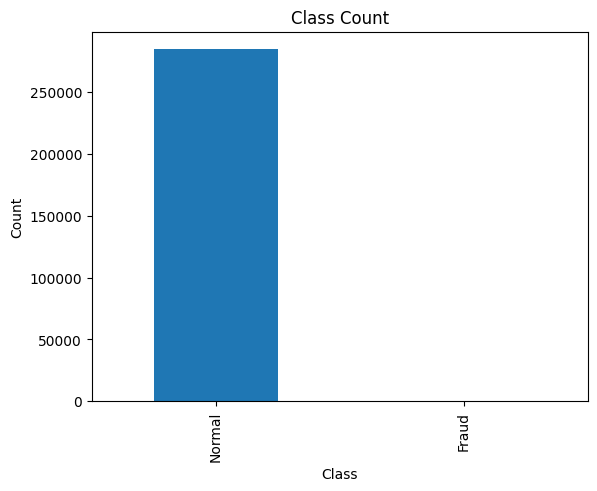

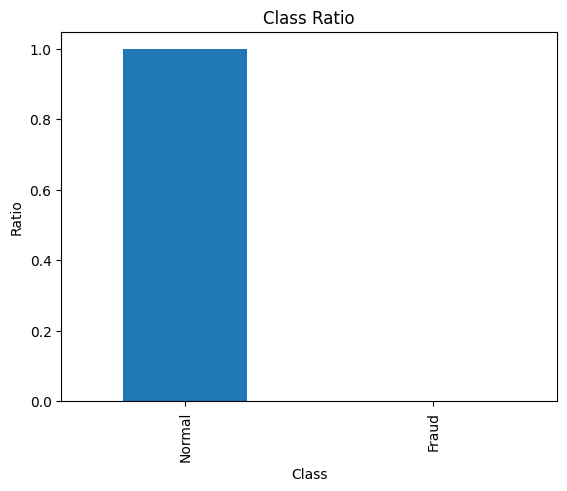

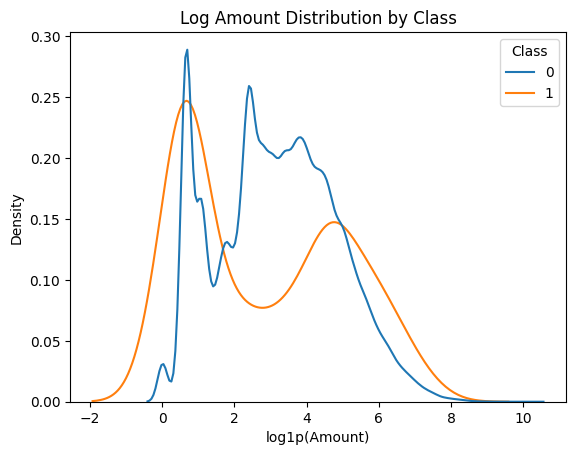

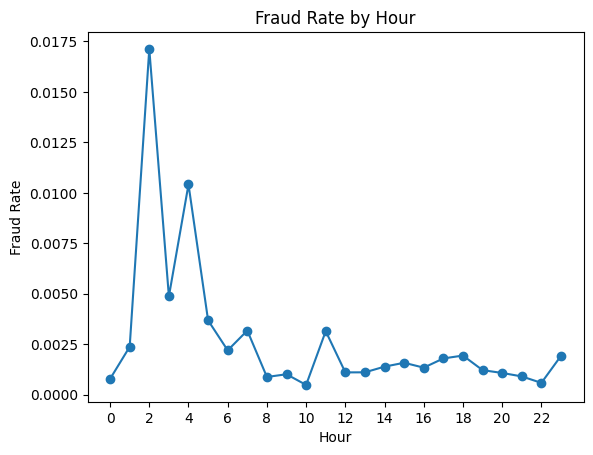

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 不正/正常の件数（棒グラフ）
ax = df["Class"].value_counts().rename(index={0: "Normal", 1: "Fraud"}).plot(kind="bar")
ax.set_title("Class Count")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.show()

# 不正/正常の割合（棒グラフ）
ax = (df["Class"].value_counts(normalize=True)
      .rename(index={0: "Normal", 1: "Fraud"})
      .plot(kind="bar"))
ax.set_title("Class Ratio")
ax.set_xlabel("Class")
ax.set_ylabel("Ratio")
plt.show()

# 取引金額の分布（金額が右に長い歪んだ分布で外れ値が多いので、対数変換。高額取引を圧縮し、少額取引を拡大）
df["log_amount"] = np.log1p(df["Amount"])
sns.kdeplot(data=df, x="log_amount", hue="Class", common_norm=False)
plt.title("Log Amount Distribution by Class")
plt.xlabel("log1p(Amount)")
plt.show()

# 時間帯ごとの不正率（折れ線）
hour_rate = df.groupby("hour")["Class"].mean().sort_index()
ax = hour_rate.plot(kind="line", marker="o")
ax.set_title("Fraud Rate by Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Fraud Rate")
ax.set_xticks(range(0, 24, 2))
plt.show()


上記の結果から、以下の傾向が見られる。
- クラス比率は極端に偏っており、不正取引は全体のごく一部である（強いクラス不均衡）
- 取引金額（対数）分布では、不正取引は中〜高額側に密度が寄りやすく、正常取引とは分布形状が異なる傾向がある。
- 時間帯別の不正率は深夜〜早朝（特に2時前後）で相対的に高く、時間帯が不正に関連する可能性がある。

## 実験内容
### 実験1：◯◯の確認
- 何を変えて
- 何を比較するのか


In [ ]:
# 実験コードを書く


## 評価・可視化
- この図は何を示すのかを文章で説明する


In [ ]:
# 可視化コードを書く


## 考察
- なぜこの結果になったか
- 有効だった条件／失敗した条件
- 再現性や安定性の懸念点


## 今後の対応
- 次に試すべきこと
- 本番利用する場合の課題
